# Load libraries

In [11]:
import os
from re import search
from dfply import *

In [12]:
import sys

# If True, will install via pypi, else will install from source
stable = False
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB and stable:
    !pip install --quiet scvi-tools[tutorials]
elif IN_COLAB and not stable:
    !pip install --quiet --upgrade jsonschema
    !pip install --quiet git+https://github.com/yoseflab/scvi-tools@master#egg=scvi-tools[tutorials]
import scvi
import anndata
import scipy
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

import random
random.seed(420)

In [53]:
sc.set_figure_params(frameon=False, dpi=150, fontsize=8)

# Load settings

In [13]:
if search("ricard", os.uname()[1]):
    exec(open('/Users/ricard/gastrulation_multiome_10x/settings.py').read())
    exec(open('/Users/ricard/gastrulation_multiome_10x/utils.py').read())
    exec(open('/Users/ricard/gastrulation_multiome_10x/Gavin/pyscenic/utils.py').read())
elif search("ebi", os.uname()[1]):
    exec(open('/homes/ricard/gastrulation_multiome_10x/settings.py').read())
    exec(open('/homes/ricard/gastrulation_multiome_10x/utils.py').read())
    exec(open('/homes/ricard/gastrulation_multiome_10x/Gavin/pyscenic/utils.py').read())
elif search("Workstation",os.uname()[1]):
    exec(open('/home/lijingyu/gastrulation/gastrulation_multiome_10x/utils.py').read())
    exec(open('/home/lijingyu/gastrulation/gastrulation_multiome_10x/settings.py').read())
else:
    exit("Computer not recognised")

# Define I/O

## input

In [14]:
io['atac_dir']=io['basedir']+'/processed/atac/'

## output

In [15]:
io['out_dir']=io['basedir']+'/processed/atac/peakVI'

In [62]:
io['adata_out']=io['out_dir']+'/adata_out.h5ad'

# Load data

In [16]:
os.chdir(io['atac_dir'])

In [17]:
# read the count matrix into a sparse matrix, and the cell and region annotations as pandas DataFrames
counts = scipy.io.mmread("peak_data.mtx").T

regions = pd.read_csv("var.tsv",header=0,index_col=0)
cells = pd.read_csv("obs.tsv", header=0,index_col=0)

# then initialize a new AnnData object

In [18]:
cells.head()

,BlacklistRatio,nDiFrags,nFrags,nMonoFrags,nMultiFrags,NucleosomeRatio,PassQC,PromoterRatio,ReadsInBlacklist,ReadsInPromoter,...,hybrid_score,doublet_call,TSSEnrichment_atac,ReadsInTSS_atac,PromoterRatio_atac,NucleosomeRatio_atac,nFrags_atac,BlacklistRatio_atac,ReadsInPeaks,FRIP
E7.5_rep1#AAACAGCCAAACCCTA-1,0.017289,13464,35225,13065,8696,1.696135,1,0.212917,1218,15000,...,1.979435,True,15.001,3765,0.212917,1.696135,35225,0.017289,37770,0.536201
E7.5_rep1#AAACAGCCATCCTGAA-1,0.013176,8183,22048,9047,4818,1.437051,1,0.153325,581,6761,...,0.140676,False,10.097,1596,0.153325,1.437051,22048,0.013176,22233,0.504333
E7.5_rep1#AAACAGCCATGCTATG-1,0.016838,12809,37415,16731,7875,1.236268,1,0.166404,1260,12452,...,0.748350,False,9.157,2770,0.166404,1.236268,37415,0.016838,36206,0.484037
E7.5_rep1#AAACATGCAACCTGGT-1,0.045107,6366,13080,3807,2907,2.435776,1,0.245413,1180,6420,...,0.270219,False,17.397,1722,0.245413,2.435776,13080,0.045107,12640,0.483513
E7.5_rep1#AAACATGCAATGAATG-1,0.015429,8281,19411,6073,5057,2.196279,1,0.214852,599,8341,...,0.307864,False,16.820,2149,0.214852,2.196279,19411,0.015429,19565,0.504227


In [23]:
adata = anndata.AnnData(X=counts, obs=cells, var=regions)

In [20]:
print(adata.shape)
# compute the threshold: 5% of the cells
min_cells = int(adata.shape[0] * 0.05)
# in-place filtering of regions

(33231, 203484)


In [24]:
sc.pp.filter_genes(adata, min_cells=min_cells)
print(adata.shape)

(33231, 65100)


In [31]:
adata=adata[adata.obs.Sample=='E8.5_rep2',:]

In [32]:
adata

View of AnnData object with n_obs × n_vars = 5558 × 65100
    obs: 'BlacklistRatio', 'nDiFrags', 'nFrags', 'nMonoFrags', 'nMultiFrags', 'NucleosomeRatio', 'PassQC', 'PromoterRatio', 'ReadsInBlacklist', 'ReadsInPromoter', 'ReadsInTSS', 'Sample', 'TSSEnrichment', 'sample', 'barcode', 'nFeature_RNA', 'nCount_RNA', 'mitochondrial_percent_RNA', 'ribosomal_percent_RNA', 'stage', 'pass_rnaQC', 'celltype.mapped', 'celltype.score', 'closest.cell', 'hybrid_score', 'doublet_call', 'TSSEnrichment_atac', 'ReadsInTSS_atac', 'PromoterRatio_atac', 'NucleosomeRatio_atac', 'nFrags_atac', 'BlacklistRatio_atac', 'ReadsInPeaks', 'FRIP'
    var: 'peak', 'n_cells'

# Set up, training, saving, and loading

In [34]:
adata = adata.copy()

In [35]:
scvi.data.setup_anndata(adata)

INFO     No batch_key inputted, assuming all cells are same batch                            
INFO     No label_key inputted, assuming all cells have same label                           
INFO     Using data from adata.X                                                             
INFO     Computing library size prior per batch                                              
INFO     Successfully registered anndata object containing 5558 cells, 65100 vars, 1 batches,
         1 labels, and 0 proteins. Also registered 0 extra categorical covariates and 0 extra
         continuous covariates.                                                              
INFO     Please do not further modify adata until model is trained.                          


/home/lijingyu/anaconda3/lib/python3.8/site-packages/scvi/data/_anndata.py:301: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  warnings.warn(


In [36]:
pvi = scvi.model.PEAKVI(adata)

In [37]:
pvi.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Epoch 144/500:  29%|██▉       | 144/500 [1:08:46<2:50:00, 28.65s/it, loss=3.56e+08, v_num=1]


In [38]:
pvi.save("trained_model", overwrite=True)

In [40]:
pvi = scvi.model.PEAKVI.load("trained_model", adata)

INFO     Using data from adata.X                                                             
INFO     Computing library size prior per batch                                              
INFO     Registered keys:['X', 'batch_indices', 'local_l_mean', 'local_l_var', 'labels']     
INFO     Successfully registered anndata object containing 5558 cells, 65100 vars, 1 batches,
         1 labels, and 0 proteins. Also registered 0 extra categorical covariates and 0 extra
         continuous covariates.                                                              


/home/lijingyu/anaconda3/lib/python3.8/site-packages/scvi/data/_anndata.py:301: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  warnings.warn(


# Visualizing and analyzing the latent space

In [42]:
latent = pvi.get_latent_representation()
adata.obsm["X_PeakVI"] = latent

print(latent.shape)

(5558, 15)


In [43]:
# compute the k-nearest-neighbor graph that is used in both clustering and umap algorithms
sc.pp.neighbors(adata, use_rep="X_PeakVI")
# compute the umap

/home/lijingyu/anaconda3/lib/python3.8/site-packages/sklearn/linear_model/least_angle.py:30: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  method='lar', copy_X=True, eps=np.finfo(np.float).eps,
/home/lijingyu/anaconda3/lib/python3.8/site-packages/sklearn/linear_model/least_angle.py:167: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  method

In [51]:
sc.tl.tsne(adata, use_rep='X_PeakVI')

In [44]:
sc.tl.umap(adata, min_dist=0.2)
# cluster the space (we use a lower resolution to get fewer clusters than the default)
sc.tl.leiden(adata, key_added="cluster_pvi", resolution=0.2)

In [57]:
adata.obs.columns

Index(['BlacklistRatio', 'nDiFrags', 'nFrags', 'nMonoFrags', 'nMultiFrags',
       'NucleosomeRatio', 'PassQC', 'PromoterRatio', 'ReadsInBlacklist',
       'ReadsInPromoter', 'ReadsInTSS', 'Sample', 'TSSEnrichment', 'sample',
       'barcode', 'nFeature_RNA', 'nCount_RNA', 'mitochondrial_percent_RNA',
       'ribosomal_percent_RNA', 'stage', 'pass_rnaQC', 'celltype.mapped',
       'celltype.score', 'closest.cell', 'hybrid_score', 'doublet_call',
       'TSSEnrichment_atac', 'ReadsInTSS_atac', 'PromoterRatio_atac',
       'NucleosomeRatio_atac', 'nFrags_atac', 'BlacklistRatio_atac',
       'ReadsInPeaks', 'FRIP', '_scvi_batch', '_scvi_labels',
       '_scvi_local_l_mean', '_scvi_local_l_var', 'cluster_pvi'],
      dtype='object')

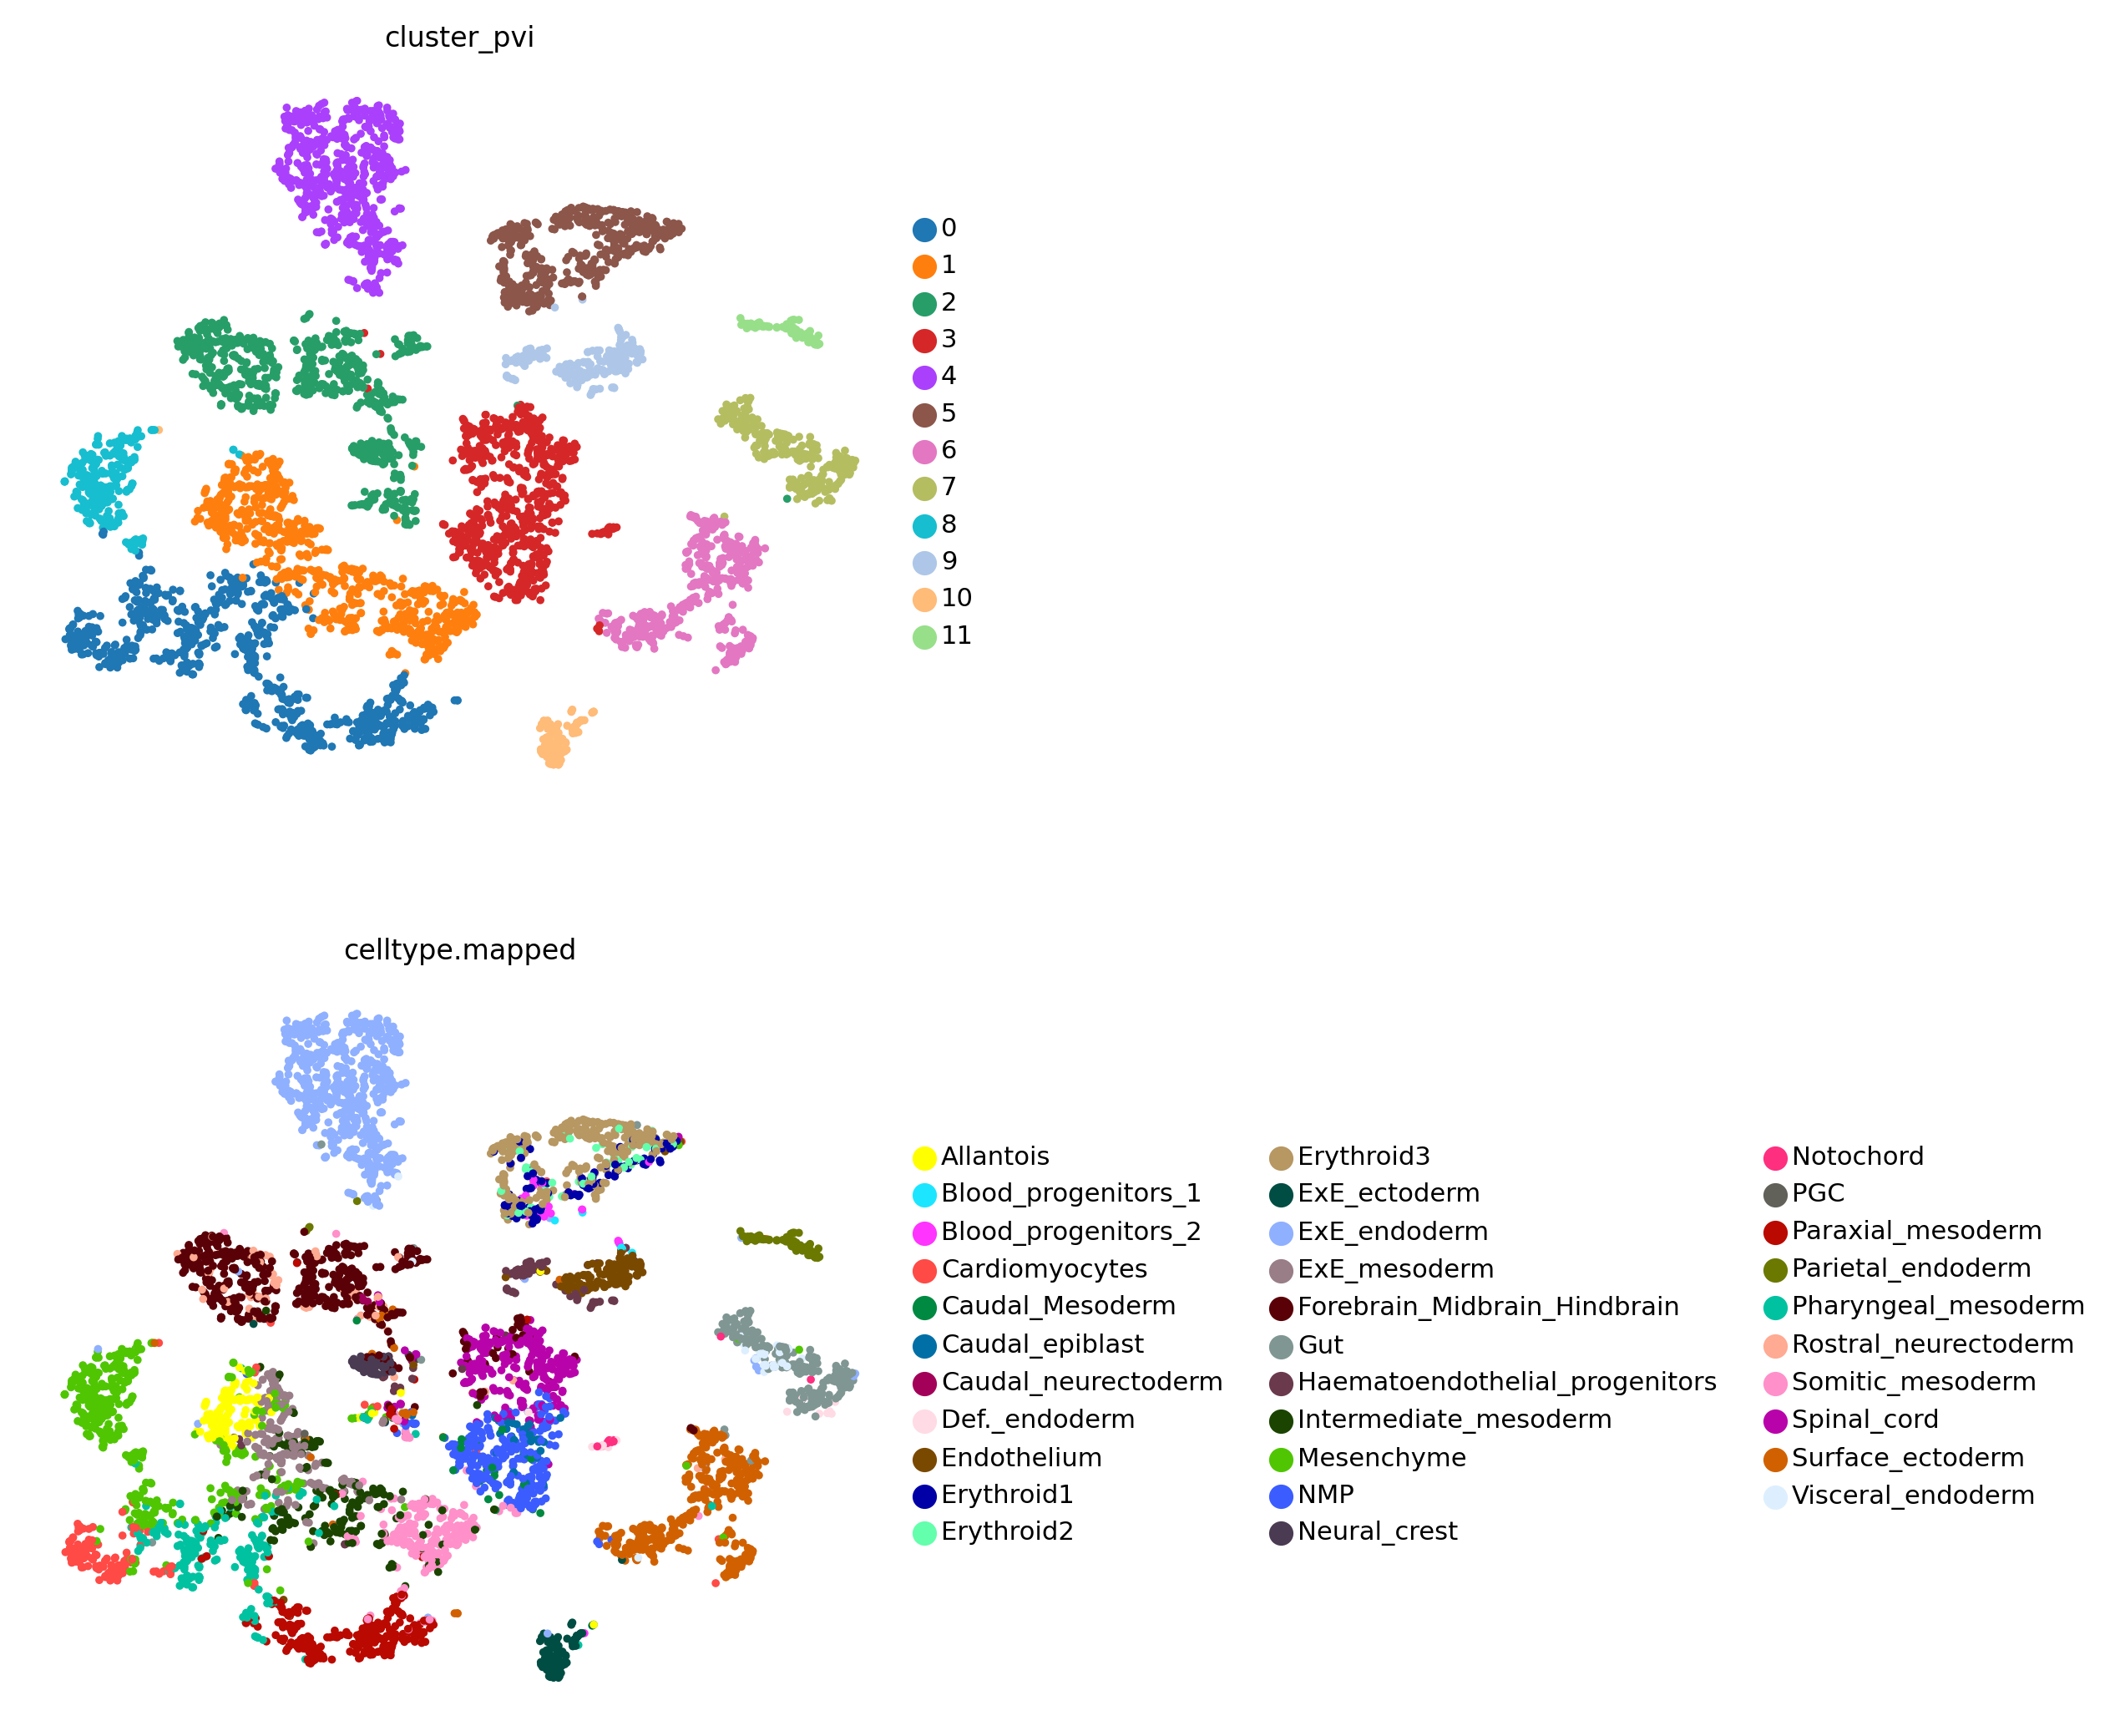

In [59]:
sc.pl.tsne(adata, color=['cluster_pvi','celltype.mapped'],ncols=1)

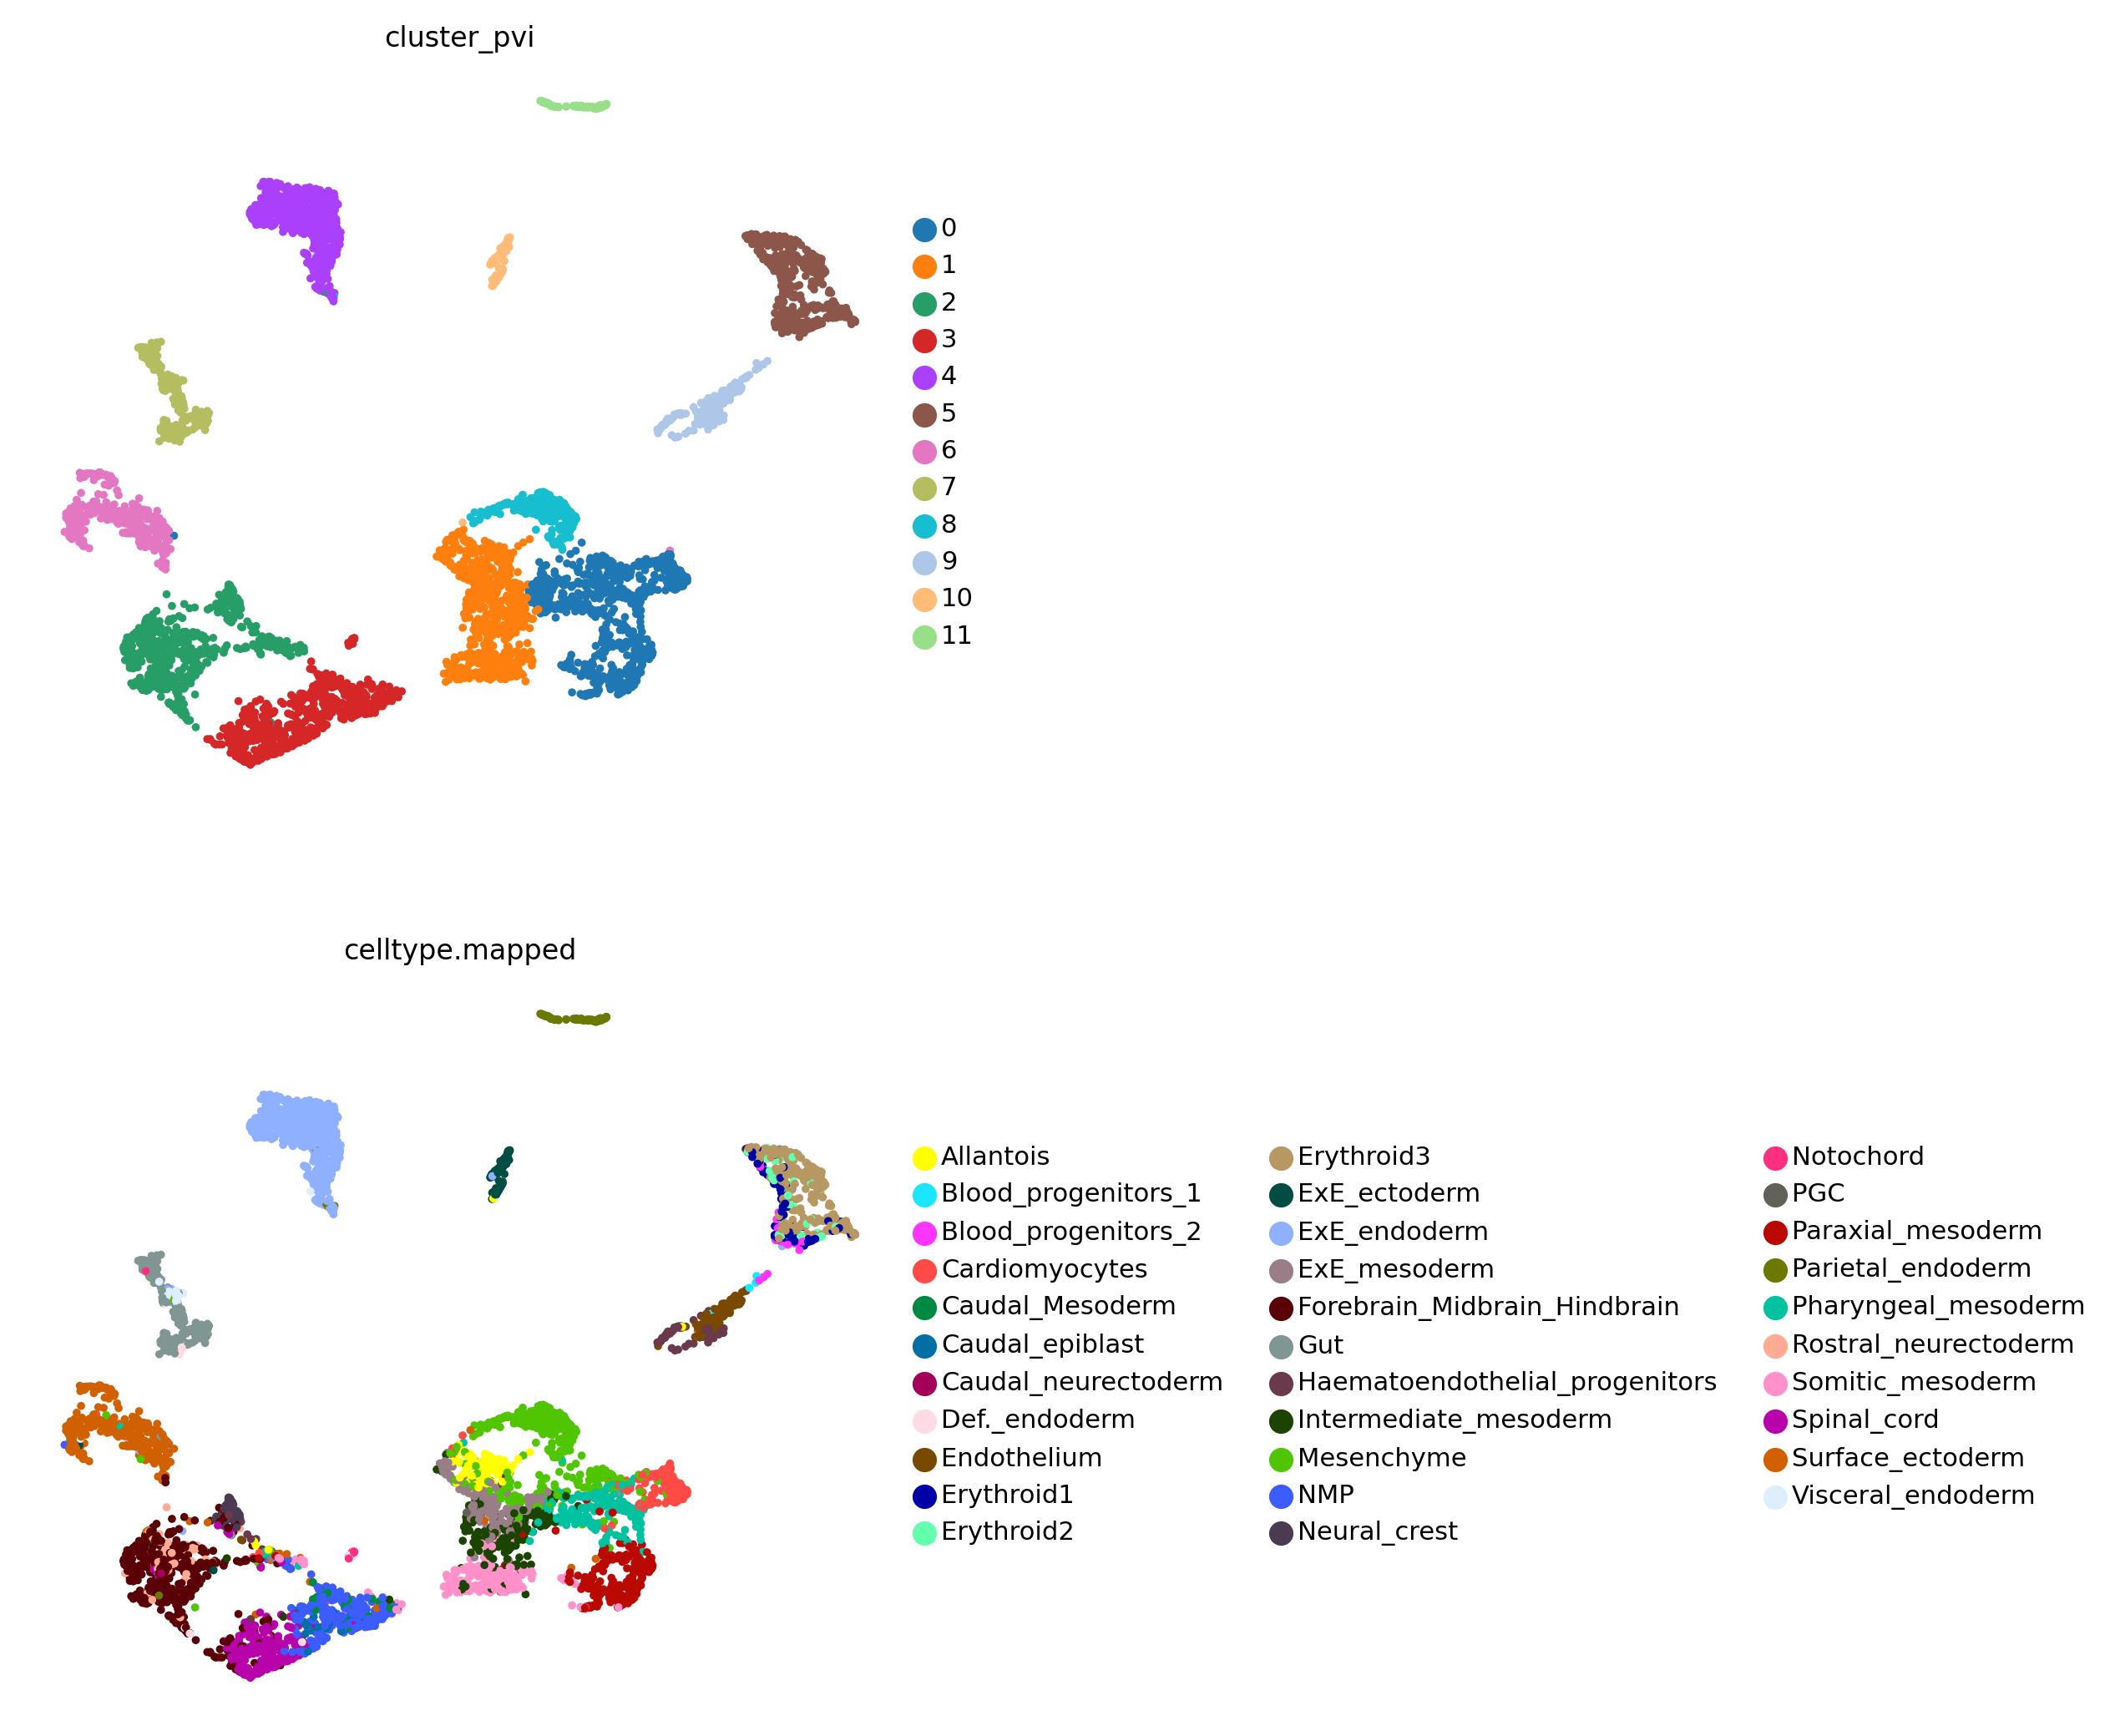

In [61]:
sc.pl.umap(adata, color=['cluster_pvi','celltype.mapped'],ncols=1)

In [63]:
adata.write(io['adata_out'])